# 💰 Controle Financeiro da Casa

Notebook interativo para visualização e gerenciamento das finanças mensais.

**Mês atual:** Janeiro/2026

> ⚠️ **Primeiro uso:** Execute a célula de configuração do ambiente antes das demais células.

## 📚 1. Importar Bibliotecas

## ⚙️ Configuração do Ambiente

Execute esta célula primeiro para garantir compatibilidade das bibliotecas:

In [2]:
# Instalar versão compatível do NumPy
import sys
!{sys.executable} -m pip install --upgrade "numpy<2" -q

print("✅ NumPy compatível instalado!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.6.0 requires daal==2021.4.0, which is not installed.
feast 0.34.1 requires dill~=0.3.0, but you have dill 0.4.0 which is incompatible.
feast 0.34.1 requires numpy<1.25,>=1.22, but you have numpy 1.26.4 which is incompatible.
feast 0.34.1 requires pandas<2,>=1.4.3, but you have pandas 2.3.2 which is incompatible.
feast 0.34.1 requires pydantic<2,>=1, but you have pydantic 2.11.7 which is incompatible.
langchain 0.1.20 requires async-timeout<5.0.0,>=4.0.0; python_version < "3.11", but you have async-timeout 5.0.1 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
projetaai-azure 0.1.0b0 requires pandas<2.0.0,>=1

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Configurar português no matplotlib
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

print("✅ Bibliotecas importadas com sucesso!")

/home/v/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/v/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Bibliotecas importadas com sucesso!


## 📁 2. Carregar Dados

In [2]:
# Carregar dados do JSON
with open('financas_casa.json', 'r', encoding='utf-8') as f:
    dados = json.load(f)

# Extrair informações
metadata = dados['metadata']
contas = dados['contas']

# Criar DataFrame
df = pd.DataFrame(contas)

# Normalizar campos
if 'status' in df.columns and 'status_code' not in df.columns:
    df['status_code'] = df['status']
elif 'status_code' not in df.columns:
    df['status_code'] = 'aberto'

print(f"📅 Mês: {metadata['mes']}/{metadata['ano']}")
print(f"📊 Total de contas: {len(df)}")
print(f"✅ Dados carregados com sucesso!\n")

df.head()

📅 Mês: 1/2026
📊 Total de contas: 23
✅ Dados carregados com sucesso!



,categoria,nome,vencimento,valor,status_code,parcela_atual,total_parcelas
0,CASA,Aluguel,10,1325.00,pago,NaN,NaN
1,CASA,Condominio,11,350.00,pago,NaN,NaN
2,CASA,Luz,13,263.06,aberto,NaN,NaN
3,CASA,Internet,10,113.55,aberto,NaN,NaN
4,CASA,Vivo,10,66.80,aberto,NaN,NaN


## 📊 3. Resumo Geral

In [3]:
# Calcular totais
total_mes = df['valor'].sum()
total_pago = df[df['status_code'] == 'pago']['valor'].sum()
total_a_pagar = df[df['status_code'].isin(['aberto', 'atrasado'])]['valor'].sum()

# Totais por categoria
total_casa = df[df['categoria'] == 'CASA']['valor'].sum()
total_v = df[df['categoria'] == 'V']['valor'].sum()
total_m = df[df['categoria'] == 'M']['valor'].sum()

# Criar resumo visual
print("="*60)
print(f"💰 RESUMO FINANCEIRO - {metadata['mes']}/{metadata['ano']}")
print("="*60)
print(f"\n📈 TOTAIS GERAIS:")
print(f"   Total do Mês:    R$ {total_mes:>10,.2f}")
print(f"   ✅ Pago:         R$ {total_pago:>10,.2f} ({(total_pago/total_mes*100):.1f}%)")
print(f"   ⏰ A Pagar:      R$ {total_a_pagar:>10,.2f} ({(total_a_pagar/total_mes*100):.1f}%)")
print(f"\n🏷️  TOTAIS POR CATEGORIA:")
print(f"   🏠 CASA:         R$ {total_casa:>10,.2f} ({(total_casa/total_mes*100):.1f}%)")
print(f"   👤 V:            R$ {total_v:>10,.2f} ({(total_v/total_mes*100):.1f}%)")
print(f"   👤 M:            R$ {total_m:>10,.2f} ({(total_m/total_mes*100):.1f}%)")
print("="*60)

💰 RESUMO FINANCEIRO - 1/2026

📈 TOTAIS GERAIS:
   Total do Mês:    R$  14,437.16
   ✅ Pago:         R$   2,471.21 (17.1%)
   ⏰ A Pagar:      R$  11,965.95 (82.9%)

🏷️  TOTAIS POR CATEGORIA:
   🏠 CASA:         R$   3,174.41 (22.0%)
   👤 V:            R$   8,949.14 (62.0%)
   👤 M:            R$   2,313.61 (16.0%)


## 📈 4. Visualizações

### 4.1 Distribuição por Status

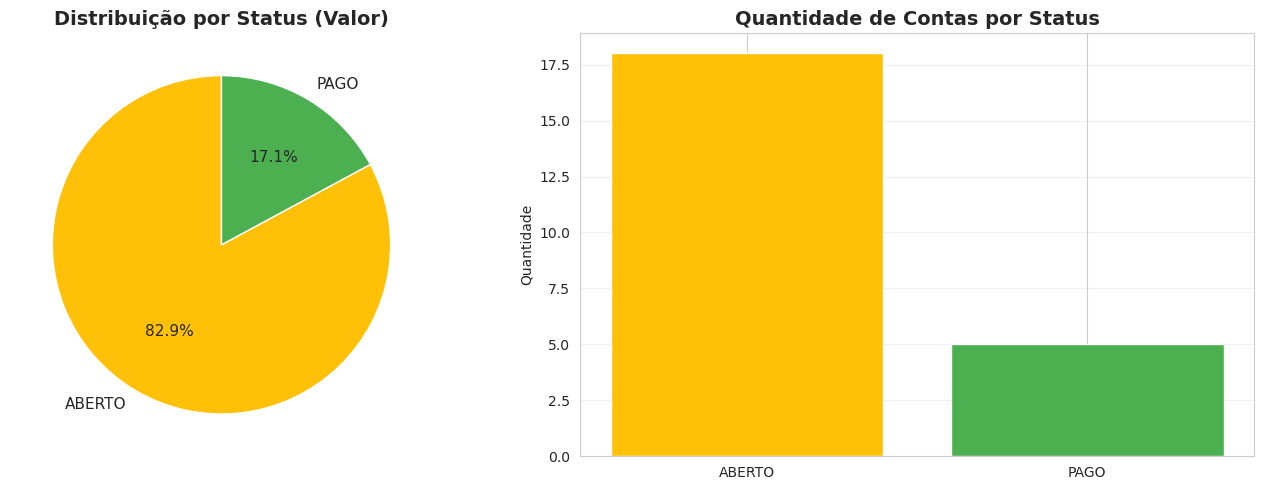

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pizza - Status
status_totais = df.groupby('status_code')['valor'].sum()
cores_status = {'pago': '#4CAF50', 'aberto': '#FFC107', 'atrasado': '#F44336'}
cores = [cores_status.get(s, '#9E9E9E') for s in status_totais.index]

ax1.pie(status_totais.values, labels=status_totais.index.str.upper(), autopct='%1.1f%%',
        startangle=90, colors=cores, textprops={'size': 11})
ax1.set_title('Distribuição por Status (Valor)', fontsize=14, fontweight='bold')

# Gráfico de barras - Quantidade por status
status_count = df['status_code'].value_counts()
cores_count = [cores_status.get(s, '#9E9E9E') for s in status_count.index]

ax2.bar(status_count.index.str.upper(), status_count.values, color=cores_count)
ax2.set_title('Quantidade de Contas por Status', fontsize=14, fontweight='bold')
ax2.set_ylabel('Quantidade')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Distribuição por Categoria

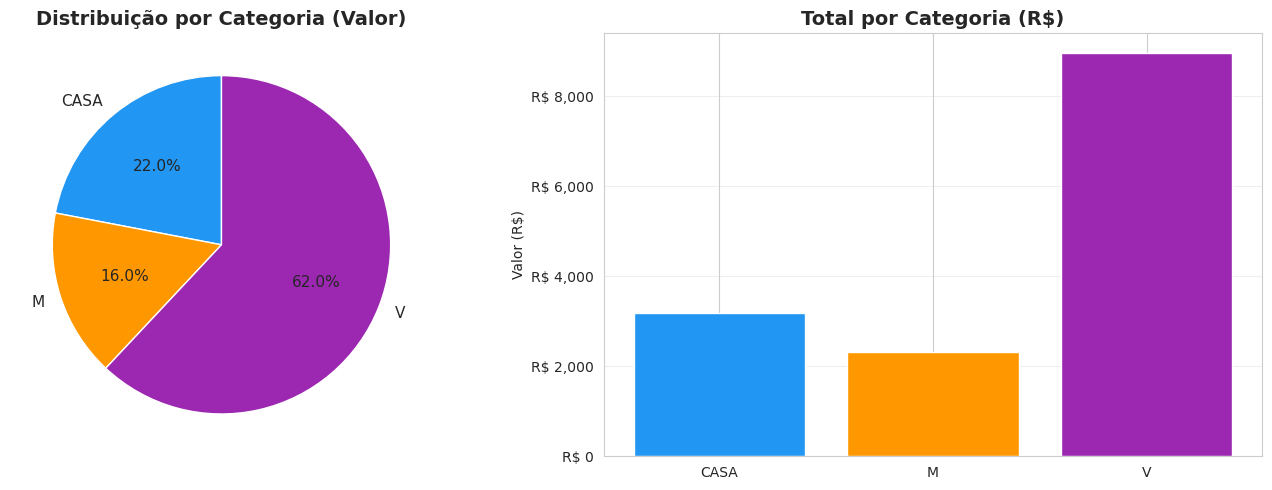

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pizza - Categoria
categoria_totais = df.groupby('categoria')['valor'].sum()
cores_cat = {'CASA': '#2196F3', 'V': '#9C27B0', 'M': '#FF9800'}
cores = [cores_cat.get(c, '#9E9E9E') for c in categoria_totais.index]

ax1.pie(categoria_totais.values, labels=categoria_totais.index, autopct='%1.1f%%',
        startangle=90, colors=cores, textprops={'size': 11})
ax1.set_title('Distribuição por Categoria (Valor)', fontsize=14, fontweight='bold')

# Gráfico de barras - Valor por categoria
ax2.bar(categoria_totais.index, categoria_totais.values, color=cores)
ax2.set_title('Total por Categoria (R$)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Valor (R$)')
ax2.grid(axis='y', alpha=0.3)

# Formatar eixo Y com valores monetários
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

### 4.3 Top 10 Maiores Contas

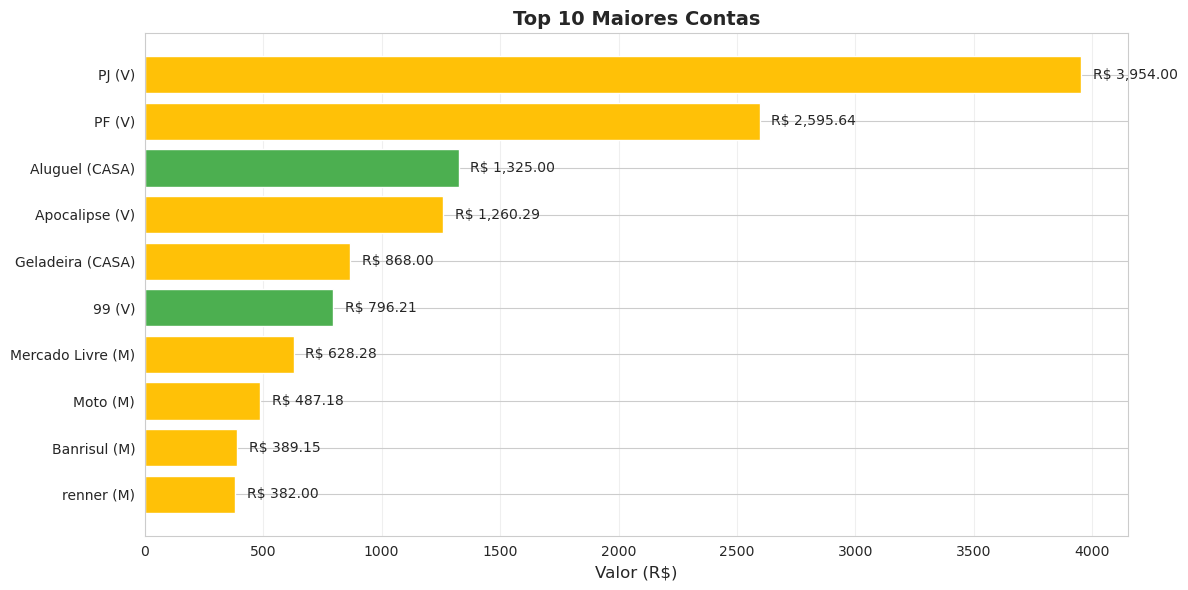

In [6]:
# Top 10 contas mais altas
top10 = df.nlargest(10, 'valor')[['nome', 'valor', 'categoria', 'status_code']].copy()

plt.figure(figsize=(12, 6))
cores_top = [cores_status.get(s, '#9E9E9E') for s in top10['status_code']]

plt.barh(range(len(top10)), top10['valor'], color=cores_top)
plt.yticks(range(len(top10)), [f"{row['nome']} ({row['categoria']})" for _, row in top10.iterrows()])
plt.xlabel('Valor (R$)', fontsize=12)
plt.title('Top 10 Maiores Contas', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(top10['valor']):
    plt.text(v + 50, i, f'R$ {v:,.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4.4 Calendário de Vencimentos

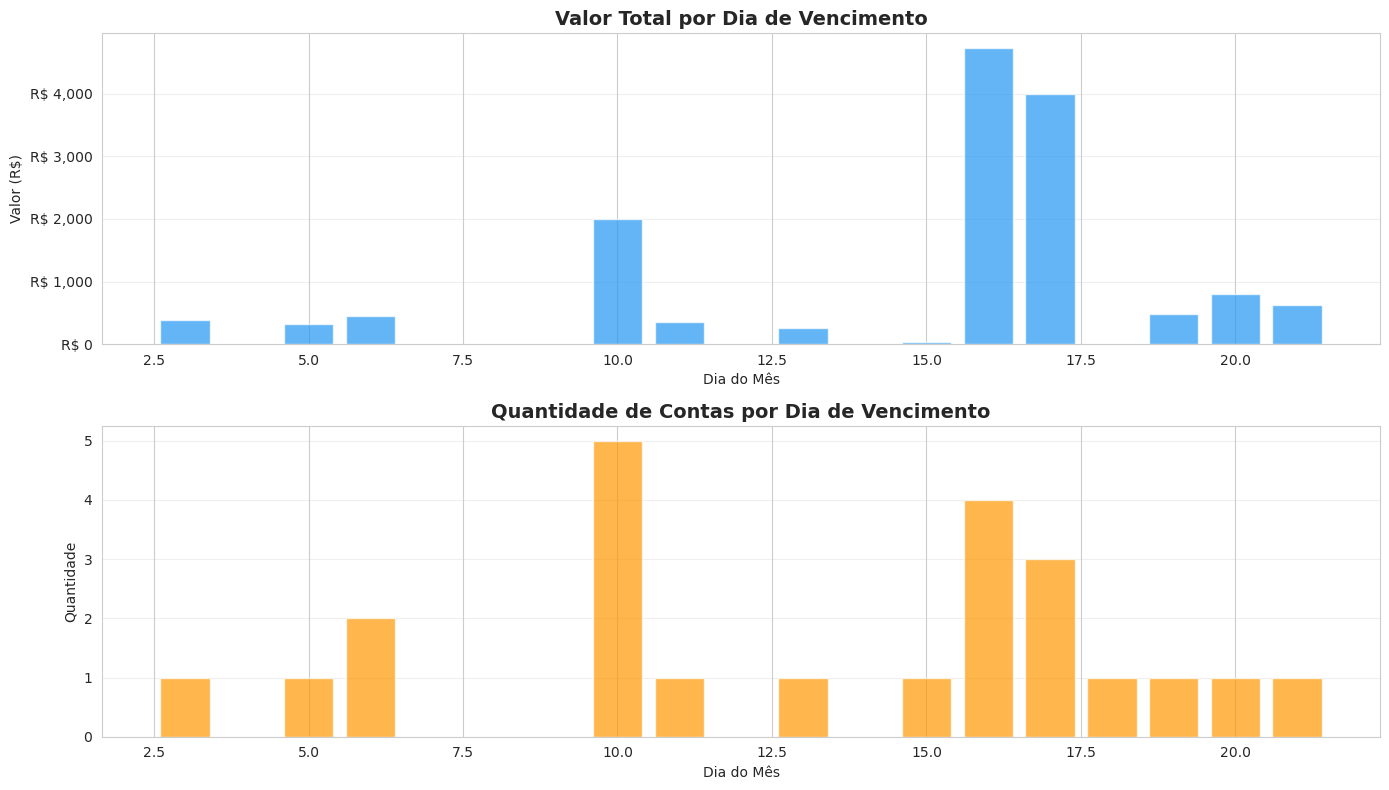

In [7]:
# Agrupar por vencimento
df_venc = df.copy()
df_venc['dia'] = df_venc['vencimento']
vencimentos = df_venc.groupby('dia').agg({
    'valor': 'sum',
    'nome': 'count'
}).rename(columns={'nome': 'quantidade'}).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1: Valor por dia
ax1.bar(vencimentos['dia'], vencimentos['valor'], color='#2196F3', alpha=0.7)
ax1.set_title('Valor Total por Dia de Vencimento', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dia do Mês')
ax1.set_ylabel('Valor (R$)')
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

# Gráfico 2: Quantidade por dia
ax2.bar(vencimentos['dia'], vencimentos['quantidade'], color='#FF9800', alpha=0.7)
ax2.set_title('Quantidade de Contas por Dia de Vencimento', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dia do Mês')
ax2.set_ylabel('Quantidade')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 5. Tabelas Detalhadas

### 5.1 Todas as Contas (Ordenadas por Vencimento)

In [8]:
# Criar cópia formatada
df_display = df.copy()

# Adicionar informação de parcelas se existir
if 'parcela_atual' in df_display.columns and 'total_parcelas' in df_display.columns:
    df_display['parcelas'] = df_display.apply(
        lambda x: f"{x['parcela_atual']}/{x['total_parcelas']}" 
        if pd.notna(x['parcela_atual']) and pd.notna(x['total_parcelas']) 
        else '-', 
        axis=1
    )
else:
    df_display['parcelas'] = '-'

# Formatar valor
df_display['valor_fmt'] = df_display['valor'].apply(lambda x: f"R$ {x:,.2f}")

# Selecionar e ordenar colunas
colunas_exibir = ['vencimento', 'nome', 'categoria', 'valor_fmt', 'parcelas', 'status_code']
df_display = df_display[colunas_exibir].sort_values('vencimento')
df_display.columns = ['Venc.', 'Nome', 'Cat.', 'Valor', 'Parcelas', 'Status']

# Aplicar estilo
def colorir_status(val):
    cores = {
        'pago': 'background-color: #C8E6C9',
        'aberto': 'background-color: #FFF9C4',
        'atrasado': 'background-color: #FFCDD2'
    }
    return cores.get(val, '')

df_display.style.applymap(colorir_status, subset=['Status'])

,Venc.,Nome,Cat.,Valor,Parcelas,Status
21,3,renner,M,R$ 382.00,-,aberto
20,5,JC,M,R$ 327.00,1.0/7.0,aberto
12,6,Contadora,V,R$ 300.00,-,aberto
6,6,Cadmia,CASA,R$ 158.00,-,aberto
0,10,Aluguel,CASA,"R$ 1,325.00",-,pago
16,10,Banrisul,M,R$ 389.15,-,aberto
22,10,curso,M,R$ 100.00,1.0/3.0,aberto
4,10,Vivo,CASA,R$ 66.80,-,aberto
3,10,Internet,CASA,R$ 113.55,-,aberto
1,11,Condominio,CASA,R$ 350.00,-,pago


### 5.2 Contas em Aberto

In [9]:
# Filtrar contas em aberto
df_aberto = df[df['status_code'] == 'aberto'].copy()

if len(df_aberto) > 0:
    # Formatar
    df_aberto['valor_fmt'] = df_aberto['valor'].apply(lambda x: f"R$ {x:,.2f}")
    
    if 'parcela_atual' in df_aberto.columns:
        df_aberto['parcelas'] = df_aberto.apply(
            lambda x: f"{x['parcela_atual']}/{x['total_parcelas']}" 
            if pd.notna(x.get('parcela_atual')) and pd.notna(x.get('total_parcelas')) 
            else '-', 
            axis=1
        )
    else:
        df_aberto['parcelas'] = '-'
    
    # Exibir
    colunas = ['vencimento', 'nome', 'categoria', 'valor_fmt', 'parcelas']
    df_show = df_aberto[colunas].sort_values('vencimento')
    df_show.columns = ['Venc.', 'Nome', 'Cat.', 'Valor', 'Parcelas']
    
    print(f"⏰ Total em aberto: R$ {df_aberto['valor'].sum():,.2f}\n")
    display(df_show.reset_index(drop=True))
else:
    print("✅ Nenhuma conta em aberto!")

⏰ Total em aberto: R$ 11,965.95



,Venc.,Nome,Cat.,Valor,Parcelas
0,3,renner,M,R$ 382.00,-
1,5,JC,M,R$ 327.00,1.0/7.0
2,6,Cadmia,CASA,R$ 158.00,-
3,6,Contadora,V,R$ 300.00,-
4,10,curso,M,R$ 100.00,1.0/3.0
5,10,Internet,CASA,R$ 113.55,-
6,10,Vivo,CASA,R$ 66.80,-
7,10,Banrisul,M,R$ 389.15,-
8,13,Luz,CASA,R$ 263.06,-
9,15,Larissel,CASA,R$ 30.00,-


### 5.3 Resumo por Categoria

In [10]:
# Criar resumo por categoria e status
resumo_cat = df.groupby(['categoria', 'status_code'])['valor'].sum().unstack(fill_value=0)
resumo_cat['TOTAL'] = resumo_cat.sum(axis=1)

# Adicionar linha de total
resumo_cat.loc['TOTAL'] = resumo_cat.sum()

# Formatar valores
resumo_cat_fmt = resumo_cat.applymap(lambda x: f"R$ {x:,.2f}")

print("📊 Resumo por Categoria e Status\n")
display(resumo_cat_fmt)

📊 Resumo por Categoria e Status



status_code,aberto,pago,TOTAL
categoria,,,
CASA,"R$ 1,499.41","R$ 1,675.00","R$ 3,174.41"
M,"R$ 2,313.61",R$ 0.00,"R$ 2,313.61"
V,"R$ 8,152.93",R$ 796.21,"R$ 8,949.14"
TOTAL,"R$ 11,965.95","R$ 2,471.21","R$ 14,437.16"


## 🔧 6. Funções Úteis

### 6.1 Marcar Conta como Paga

In [11]:
def marcar_como_pago(nome_conta):
    """Marca uma conta como paga no JSON"""
    with open('financas_casa.json', 'r', encoding='utf-8') as f:
        dados = json.load(f)
    
    encontrado = False
    for conta in dados['contas']:
        if conta['nome'].lower() == nome_conta.lower():
            conta['status_code'] = 'pago'
            if 'status' in conta:
                conta['status'] = 'pago'
            encontrado = True
            break
    
    if encontrado:
        with open('financas_casa.json', 'w', encoding='utf-8') as f:
            json.dump(dados, f, ensure_ascii=False, indent=2)
        print(f"✅ Conta '{nome_conta}' marcada como PAGA!")
        return True
    else:
        print(f"❌ Conta '{nome_conta}' não encontrada.")
        return False

# Exemplo de uso:
# marcar_como_pago('Luz')

### 6.2 Atualizar Valor de uma Conta

In [12]:
def atualizar_valor(nome_conta, novo_valor):
    """Atualiza o valor de uma conta no JSON"""
    with open('financas_casa.json', 'r', encoding='utf-8') as f:
        dados = json.load(f)
    
    encontrado = False
    for conta in dados['contas']:
        if conta['nome'].lower() == nome_conta.lower():
            valor_antigo = conta['valor']
            conta['valor'] = float(novo_valor)
            encontrado = True
            break
    
    if encontrado:
        with open('financas_casa.json', 'w', encoding='utf-8') as f:
            json.dump(dados, f, ensure_ascii=False, indent=2)
        print(f"✅ Conta '{nome_conta}' atualizada!")
        print(f"   Valor antigo: R$ {valor_antigo:,.2f}")
        print(f"   Valor novo:   R$ {novo_valor:,.2f}")
        return True
    else:
        print(f"❌ Conta '{nome_conta}' não encontrada.")
        return False

# Exemplo de uso:
# atualizar_valor('Luz', 280.50)

### 6.3 Buscar Conta

In [13]:
def buscar_conta(termo):
    """Busca contas por nome (parcial)"""
    resultados = df[df['nome'].str.contains(termo, case=False, na=False)].copy()
    
    if len(resultados) > 0:
        resultados['valor_fmt'] = resultados['valor'].apply(lambda x: f"R$ {x:,.2f}")
        
        colunas = ['nome', 'categoria', 'vencimento', 'valor_fmt', 'status_code']
        display_cols = [c for c in colunas if c in resultados.columns]
        
        df_show = resultados[display_cols]
        df_show.columns = ['Nome', 'Cat.', 'Venc.', 'Valor', 'Status']
        
        print(f"🔍 Encontradas {len(resultados)} conta(s):\n")
        display(df_show.reset_index(drop=True))
    else:
        print(f"❌ Nenhuma conta encontrada com '{termo}'")

# Exemplo de uso:
# buscar_conta('luz')

## 📤 7. Exportar Relatórios

### 7.1 Gerar CSV Detalhado

In [ ]:
# Gerar CSV com todas as informações
df_export = df.copy()
df_export = df_export.sort_values(['categoria', 'vencimento'])

# Salvar
df_export.to_csv('financas_casa.csv', index=False, encoding='utf-8')
print("✅ CSV detalhado gerado: financas_casa.csv")

### 7.2 Gerar Resumo Mensal

In [14]:
# Criar resumo mensal
resumo = {
    'Mês': f"{metadata['mes']}/{metadata['ano']}",
    'Total do Mês': f"{total_mes:.2f}",
    'Total Pago': f"{total_pago:.2f}",
    'Total a Pagar': f"{total_a_pagar:.2f}",
    'Total CASA': f"{total_casa:.2f}",
    'Total V': f"{total_v:.2f}",
    'Total M': f"{total_m:.2f}"
}

df_resumo = pd.DataFrame([resumo])
df_resumo.to_csv('resumo_mensal.csv', index=False, encoding='utf-8')

print("✅ Resumo mensal gerado: resumo_mensal.csv")
display(df_resumo)

✅ Resumo mensal gerado: resumo_mensal.csv


,Mês,Total do Mês,Total Pago,Total a Pagar,Total CASA,Total V,Total M
0,1/2026,14437.16,2471.21,11965.95,3174.41,8949.14,2313.61


## 🎯 8. Ações Rápidas

### Recarregar Dados
Execute a célula abaixo para recarregar os dados após fazer alterações:

In [ ]:
# Recarregar dados
with open('financas_casa.json', 'r', encoding='utf-8') as f:
    dados = json.load(f)

metadata = dados['metadata']
df = pd.DataFrame(dados['contas'])

if 'status' in df.columns and 'status_code' not in df.columns:
    df['status_code'] = df['status']

print(f"✅ Dados recarregados! Total de contas: {len(df)}")

---

## 📝 Notas

- **Para marcar como paga:** Use `marcar_como_pago('Nome da Conta')`
- **Para atualizar valor:** Use `atualizar_valor('Nome da Conta', novo_valor)`
- **Para buscar:** Use `buscar_conta('termo')`
- **Para recarregar:** Execute a célula "Recarregar Dados"

### Scripts disponíveis no terminal:
- `python update.py -i` - Modo interativo completo
- `python maths_month.py` - Calcular resumo mensal
- `python reset_month.py` - Resetar mês